<a href="https://colab.research.google.com/github/freezetea/data-science-2026/blob/main/Pertemuan12_%5BAlif_Firdaus_Hidayatullah%5D_%5B250401020166%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Alif Firdaus Hidayatullah
NIM : 250401020166
Kelas : IF405
Program Studi : S1 PJJ Informatika

**Langkah 1: Generate & Eksplorasi Dataset Transaksi**

In [37]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

produk = [
    "Roti", "Selai", "Susu", "Sereal", "Telur",
    "Keju", "Kopi", "Gula", "Teh", "Mentega"
]

# Buat 50 transaksi, setiap transaksi berisi 2–5 produk.
transaksi = []

for _ in range(50):
    n_item = np.random.randint(2, 6)

    item_terpilih = np.random.choice(
        produk,
        n_item,
        replace=False
    ).tolist()

    transaksi.append(item_terpilih)

# Suntikkan pola: Roti sering dibeli bersama Selai.
for i in range(20):
    if "Roti" in transaksi[i] and "Selai" not in transaksi[i]:
        transaksi[i].append("Selai")

print("Contoh transaksi:", transaksi[:3])
print("Jumlah transaksi:", len(transaksi))

Contoh transaksi: [['Keju', 'Roti', 'Mentega', 'Kopi', 'Selai'], ['Roti', 'Kopi', 'Teh', 'Selai', 'Mentega'], ['Kopi', 'Susu', 'Teh']]
Jumlah transaksi: 50


**Eksplorasi frekuensi setiap produk:**

Frekuensi setiap produk:
Selai      26
Teh        23
Mentega    21
Telur      18
Keju       17
Roti       16
Kopi       16
Susu       16
Gula       16
Sereal      9
Name: count, dtype: int64


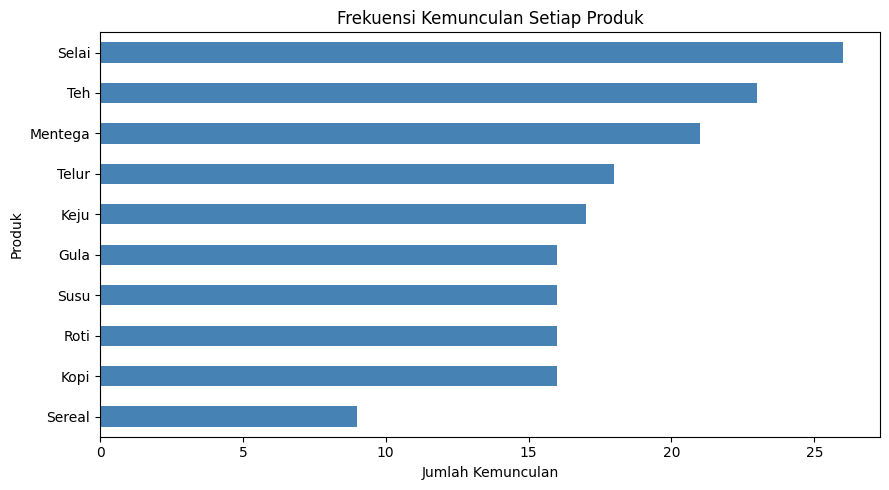

In [17]:
frekuensi_produk = pd.Series(
    [item for trx in transaksi for item in trx]
).value_counts()

print("Frekuensi setiap produk:")
print(frekuensi_produk)

plt.figure(figsize=(9, 5))

frekuensi_produk.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Frekuensi Kemunculan Setiap Produk")
plt.xlabel("Jumlah Kemunculan")
plt.ylabel("Produk")
plt.tight_layout()
plt.show()

**Sel Markdown:**

In [24]:
### Interpretasi Langkah 1

#Dataset sintetis terdiri dari 50 transaksi dan 10 jenis produk. Setiap transaksi
#berisi 2 sampai 5 produk. Pada 20 transaksi pertama, ditambahkan pola tersembunyi berupa
#Roti yang lebih sering muncul bersama Selai.

#Grafik frekuensi menunjukkan jumlah kemunculan setiap produk dalam seluruh
#transaksi. Pola Roti dan Selai diharapkan dapat ditemukan kembali melalui
#algoritma Apriori.

**Langkah 2: One-Hot Encoding Transaksi**

In [26]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_ary = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(
    te_ary,
    columns=te.columns_
)

print(df.head())
print("Ukuran data:", df.shape)

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False
Ukuran data: (50, 10)


**Sel Markdown:**

### Interpretasi Langkah 2

#TransactionEncoder mengubah daftar transaksi menjadi tabel one-hot encoding.
#Setiap baris mewakili satu transaksi dan setiap kolom mewakili satu produk.

#Nilai True berarti produk terdapat dalam transaksi, sedangkan False berarti
#produk tidak terdapat dalam transaksi. Data one-hot encoding ini digunakan
#sebagai input untuk algoritma Apriori.

**Langkah 3: Cari Frequent Itemset dengan Apriori**

**Langkah 4: Bentuk & Saring Aturan Asosiasi**

**Langkah 5: Rekomender Sederhana dengan Content-Based Filtering**

**Langkah 3: Cari Frequent Itemset dengan Apriori**

In [27]:
from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(
        df,
        min_support=ms,
        use_colnames=True
    )

    print(
        f"min_support={ms}: "
        f"{len(freq)} itemset ditemukan"
    )

# Gunakan min_support yang menghasilkan jumlah itemset wajar.
freq_items = apriori(
    df,
    min_support=0.1,
    use_colnames=True
)

freq_items = freq_items.sort_values(
    "support",
    ascending=False
).reset_index(drop=True)

print("\n10 frequent itemset teratas:")
print(freq_items.head(10))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan

10 frequent itemset teratas:
   support      itemsets
0     0.52       (Selai)
1     0.46         (Teh)
2     0.42     (Mentega)
3     0.36       (Telur)
4     0.34        (Keju)
5     0.32        (Gula)
6     0.32        (Kopi)
7     0.32        (Roti)
8     0.32        (Susu)
9     0.24  (Teh, Selai)


**Visualisasi frequent itemset:**

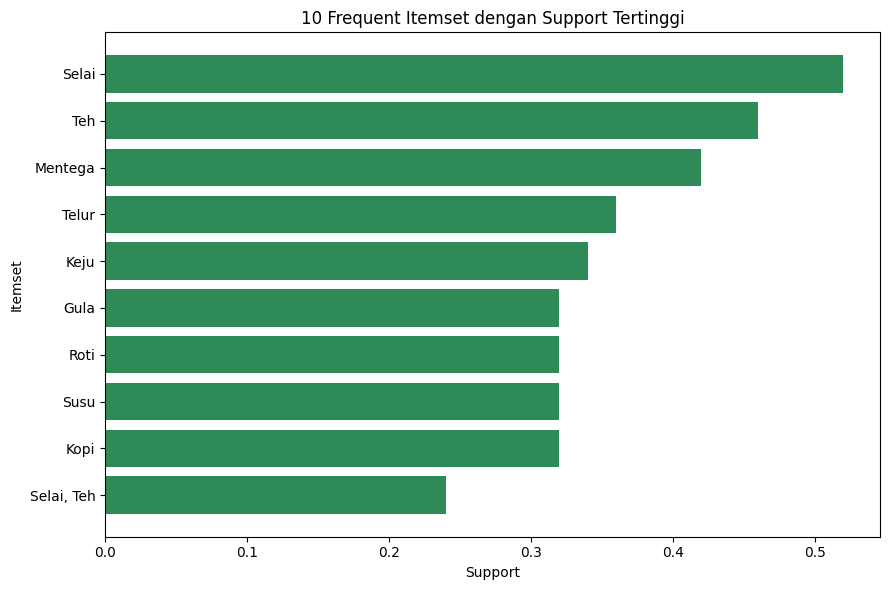

In [28]:
top_itemsets = (
    freq_items
    .sort_values("support", ascending=True)
    .tail(10)
    .copy()
)

top_itemsets["nama_itemset"] = top_itemsets["itemsets"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_itemsets["nama_itemset"],
    top_itemsets["support"],
    color="seagreen"
)

plt.title("10 Frequent Itemset dengan Support Tertinggi")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.tight_layout()
plt.show()

**Sel Markdown:**

### Interpretasi Langkah 3

#Semakin kecil nilai minimum support, semakin banyak frequent itemset yang
#ditemukan. Sebaliknya, semakin besar nilai minimum support, semakin sedikit
#itemset yang memenuhi syarat.

#Minimum support 0,1 berarti itemset harus muncul pada sekurang-kurangnya 10%
#transaksi. Karena terdapat 50 transaksi, itemset tersebut harus muncul pada
#sekitar 5 transaksi atau lebih.

#Nilai 0,1 digunakan karena masih dapat menemukan pola pembelian yang cukup sering
#tanpa menghasilkan terlalu banyak itemset.

**Langkah 4: Bentuk dan Saring Aturan Asosiasi**

In [29]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

# Pertahankan aturan dengan lift lebih besar dari 1.
rules = (
    rules[rules["lift"] > 1]
    .sort_values("lift", ascending=False)
    .reset_index(drop=True)
)

kolom_rules = [
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]

print("10 aturan asosiasi teratas:")
print(rules[kolom_rules].head(10))

10 aturan asosiasi teratas:
        antecedents consequents  support  confidence      lift
0       (Teh, Keju)     (Telur)     0.12    0.857143  2.380952
1  (Mentega, Selai)      (Kopi)     0.10    0.625000  1.953125
2      (Roti, Gula)     (Selai)     0.10    1.000000  1.923077
3          (Sereal)   (Mentega)     0.14    0.777778  1.851852
4      (Teh, Telur)      (Keju)     0.12    0.600000  1.764706
5     (Kopi, Selai)   (Mentega)     0.10    0.714286  1.700680
6     (Keju, Telur)       (Teh)     0.12    0.750000  1.630435
7     (Gula, Selai)      (Roti)     0.10    0.500000  1.562500
8   (Kopi, Mentega)     (Selai)     0.10    0.714286  1.373626
9            (Roti)     (Selai)     0.22    0.687500  1.322115


**Tampilkan aturan paling kuat:**

In [30]:
if not rules.empty:
    aturan_terkuat = rules.iloc[0]

    antecedent_terkuat = ", ".join(
        sorted(list(aturan_terkuat["antecedents"]))
    )

    consequent_terkuat = ", ".join(
        sorted(list(aturan_terkuat["consequents"]))
    )

    print("Aturan paling kuat:")
    print(f"{antecedent_terkuat} → {consequent_terkuat}")
    print(
        "Support:",
        round(aturan_terkuat["support"], 3)
    )
    print(
        "Confidence:",
        round(aturan_terkuat["confidence"], 3)
    )
    print(
        "Lift:",
        round(aturan_terkuat["lift"], 3)
    )
else:
    print("Tidak ditemukan aturan yang memenuhi kriteria.")

Aturan paling kuat:
Keju, Teh → Telur
Support: 0.12
Confidence: 0.857
Lift: 2.381


**Sel Markdown:**

### Interpretasi Langkah 4

#Aturan paling kuat adalah aturan yang berada pada baris pertama karena telah
#diurutkan berdasarkan nilai lift tertinggi.

#Support menunjukkan proporsi transaksi yang mengandung antecedent dan
#consequent. Confidence menunjukkan kemungkinan consequent dibeli ketika
#antecedent telah dibeli. Lift menunjukkan kekuatan hubungan kedua produk
#dibandingkan dengan kondisi ketika keduanya tidak memiliki hubungan.

#Nilai lift lebih besar dari 1 menunjukkan hubungan positif. Artinya, kedua
#produk lebih sering dibeli bersama daripada yang diharapkan secara kebetulan.

#Jika aturan Roti → Selai muncul, aturan tersebut masuk akal secara bisnis karena
#Roti dan Selai merupakan produk pelengkap. Toko dapat memanfaatkan pola tersebut
#untuk promosi bundling, rekomendasi produk, atau meletakkan kedua produk secara
#berdekatan.

**Langkah 5: Rekomendasi Content-Based Filtering**

In [31]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    "produk": produk,
    "kategori": [
        "Bakery",
        "Bakery",
        "Dairy",
        "Bakery",
        "Dairy",
        "Dairy",
        "Minuman",
        "Bumbu",
        "Minuman",
        "Dairy"
    ]
})

print("Katalog produk:")
print(katalog)

Katalog produk:
    produk kategori
0     Roti   Bakery
1    Selai   Bakery
2     Susu    Dairy
3   Sereal   Bakery
4    Telur    Dairy
5     Keju    Dairy
6     Kopi  Minuman
7     Gula    Bumbu
8      Teh  Minuman
9  Mentega    Dairy


**One-hot encoding kategori dan cosine similarity:**

In [32]:
fitur = pd.get_dummies(
    katalog["kategori"],
    dtype=int
)

print("Fitur kategori:")
print(fitur)

sim_matrix = cosine_similarity(fitur)

sim_df = pd.DataFrame(
    sim_matrix,
    index=katalog["produk"],
    columns=katalog["produk"]
)

print("\nMatriks cosine similarity:")
print(sim_df)

Fitur kategori:
   Bakery  Bumbu  Dairy  Minuman
0       1      0      0        0
1       1      0      0        0
2       0      0      1        0
3       1      0      0        0
4       0      0      1        0
5       0      0      1        0
6       0      0      0        1
7       0      1      0        0
8       0      0      0        1
9       0      0      1        0

Matriks cosine similarity:
produk   Roti  Selai  Susu  Sereal  Telur  Keju  Kopi  Gula  Teh  Mentega
produk                                                                   
Roti      1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Selai     1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Susu      0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
Sereal    1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Telur     0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
Keju      0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
K

**Fungsi rekomendasi:**

In [33]:
def rekomendasi_serupa(nama_produk, top_n=3):
    if nama_produk not in katalog["produk"].values:
        return f"Produk '{nama_produk}' tidak ditemukan."

    idx = katalog.index[
        katalog["produk"] == nama_produk
    ][0]

    skor = list(enumerate(sim_matrix[idx]))

    # Hapus produk target dan similarity bernilai 0.
    skor = [
        (i, nilai)
        for i, nilai in skor
        if i != idx and nilai > 0
    ]

    skor = sorted(
        skor,
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    hasil = katalog.iloc[
        [i for i, _ in skor]
    ]["produk"].tolist()

    return hasil

print(
    "Mirip dengan Roti:",
    rekomendasi_serupa("Roti")
)

Mirip dengan Roti: ['Selai', 'Sereal']


**Hasil yang diharapkan:**

Mirip dengan Roti: ['Selai', 'Sereal']

**Sel Markdown:**

### Interpretasi Langkah 5

#Content-Based Filtering merekomendasikan produk berdasarkan kemiripan atribut
#produk. Pada percobaan ini, atribut yang digunakan adalah kategori.

#Kategori diubah menjadi one-hot encoding, kemudian kemiripan antarproduk dihitung
#menggunakan cosine similarity. Produk dalam kategori yang sama memiliki
#similarity 1, sedangkan produk dari kategori berbeda memiliki similarity 0.

#Roti direkomendasikan bersama Selai dan Sereal karena ketiganya berada dalam
#kategori Bakery. Metode ini tidak memerlukan data perilaku pengguna, tetapi
#kualitas rekomendasinya sangat bergantung pada atribut produk yang tersedia.

**Langkah 6: Bandingkan Kedua Pendekatan**

In [34]:
produk_target = "Roti"

# Cari aturan yang antecedent-nya mengandung produk target.
rules_terkait = rules[
    rules["antecedents"].apply(
        lambda x: produk_target in x
    )
].copy()

print("Rekomendasi dari Association Rules:")

if rules_terkait.empty:
    print(
        "Tidak ditemukan aturan untuk produk",
        produk_target
    )
else:
    print(
        rules_terkait[
            [
                "antecedents",
                "consequents",
                "confidence",
                "lift"
            ]
        ].head()
    )

print(
    "\nRekomendasi dari Content-Based:",
    rekomendasi_serupa(produk_target)
)

Rekomendasi dari Association Rules:
    antecedents consequents  confidence      lift
2  (Roti, Gula)     (Selai)      1.0000  1.923077
9        (Roti)     (Selai)      0.6875  1.322115

Rekomendasi dari Content-Based: ['Selai', 'Sereal']


**Ubah hasil association rules menjadi daftar produk:**

In [35]:
rekomendasi_asosiasi = []

for itemset in rules_terkait["consequents"]:
    for item in itemset:
        if item not in rekomendasi_asosiasi:
            rekomendasi_asosiasi.append(item)

rekomendasi_content = rekomendasi_serupa(
    produk_target
)

print(
    "Daftar rekomendasi Association Rules:",
    rekomendasi_asosiasi[:3]
)

print(
    "Daftar rekomendasi Content-Based:",
    rekomendasi_content
)

Daftar rekomendasi Association Rules: ['Selai']
Daftar rekomendasi Content-Based: ['Selai', 'Sereal']


**Periksa rekomendasi yang sama:**

In [36]:
rekomendasi_sama = set(
    rekomendasi_asosiasi
) & set(rekomendasi_content)

print(
    "Produk yang direkomendasikan oleh kedua metode:",
    list(rekomendasi_sama)
)

Produk yang direkomendasikan oleh kedua metode: ['Selai']


**Sel Markdown:**

### Perbandingan Association Rules dan Content-Based Filtering

#Association Rules memberikan rekomendasi berdasarkan pola produk yang sering
#dibeli bersama dalam data transaksi. Content-Based Filtering memberikan
#rekomendasi berdasarkan kemiripan atribut atau kategori produk.

#Apabila Selai direkomendasikan oleh kedua metode untuk produk Roti, hasil kedua
#pendekatan dapat dikatakan konsisten. Meskipun demikian, alasan di balik
#rekomendasinya berbeda.

#Association Rules merekomendasikan Selai karena pelanggan sering membeli Roti
#dan Selai secara bersamaan. Content-Based Filtering merekomendasikan Selai
#karena Roti dan Selai sama-sama berada dalam kategori Bakery.

#Association Rules lebih cocok digunakan ketika tersedia banyak data transaksi
#pelanggan. Content-Based Filtering lebih cocok ketika tersedia informasi atau
#atribut produk, termasuk untuk produk baru yang belum memiliki banyak histori
#transaksi.

#Kedua pendekatan dapat digabungkan menjadi sistem hybrid. Sistem hybrid dapat
#memberikan rekomendasi yang mempertimbangkan pola pembelian pelanggan sekaligus
#kemiripan karakteristik produk sehingga hasil rekomendasi menjadi lebih relevan.